In [1]:
%pwd
%load_ext autoreload
%autoreload 2

In [2]:
import sys
import os

project_root = os.path.abspath(os.path.join(os.getcwd(), "../../"))
if project_root not in sys.path:
    sys.path.insert(0, project_root)
from experiments.scripts.run_experiments import run_experiment
from experiments.scripts.experiment_utils import generate_experiments

INFO: NumExpr defaulting to 8 threads.


In [3]:
base_config = {
    # Experiment
    "experiment": "t_vae_torus_high",
    "random_seed": 42,
    "logging": True,

    # Dataset
    "dataset_name": "torus",
    "batch_size": 64,
    "rotation": "random",
    "translation": None,
    "n_times": 10000,
    "embedding_dim": 10,
    "major_radius": 2,
    "minor_radius": 1,
    "noise_var": 0.001,
    "deformation_amp": 0.3,
    "geodesic_distortion_amp": 0.3,

    # Model
    'model_type': 'VMFToroidalVAE',
    "data_dim": 10,
    'latent_dim': 2,    # choose latent_dim=2 for T² in R^3 
    'sftbeta': 4.5,
    'device': "cpu",
    'encoder_width': 100,
    'encoder_depth': 3,
    'decoder_width': 100,
    'decoder_depth': 3,
    'activation': "softplus",


    # Optimizer
    "learning_rate": 0.001,

    # Trainer
    'verbose': False,
    'num_epochs': 100,
    'log_interval': 100,
    'recon_loss': "MSE",
    'topo_loss': True,
    'dim_topo_loss': 0,  # Max feature dimension topological loss
    'alpha': 1.0,  # Weight for reconstruction loss
    'beta': 0.03,  # Weight for KL loss
    'gamma': 0.0,  # Weight for topological loss

    # Curvature computation
    "plot_curvatures": False,
    "compute_emp_curv": False,
    "compute_true_curv": False,
    "compute_learned_curv": False,
    "compute_rec_curv": False,
    "quadric_dim": 1,
    "n_plot_points": 3000,
    "n_points_emp_curv": 2000,
    "n_points_pullback_curv": 2000, 
    "k": 80,
    "smoothing": True,

    # Persistent homology
    "persistent_homology": False,
    "n_points_pers_hom": 1000,
    "scale": False,
    "homology_dimensions": [0, 1]
}

param_grid = {
    'beta': [0.0,0.08,1.0] * 7 ,
    'gamma': [0.0] * 3 + ([1.0] * 3 + [100.0] * 3) * 3,
    'dim_topo_loss': [0] * 9 + [1] * 6 + [2] * 6,
}



all_configs = generate_experiments(base_config, param_grid)


Running exp00_t_vae_torus_high. 
Description: beta=0.0, gamma=0.0, dim_topo_loss=0
--------------------------------------------------------------------------------------


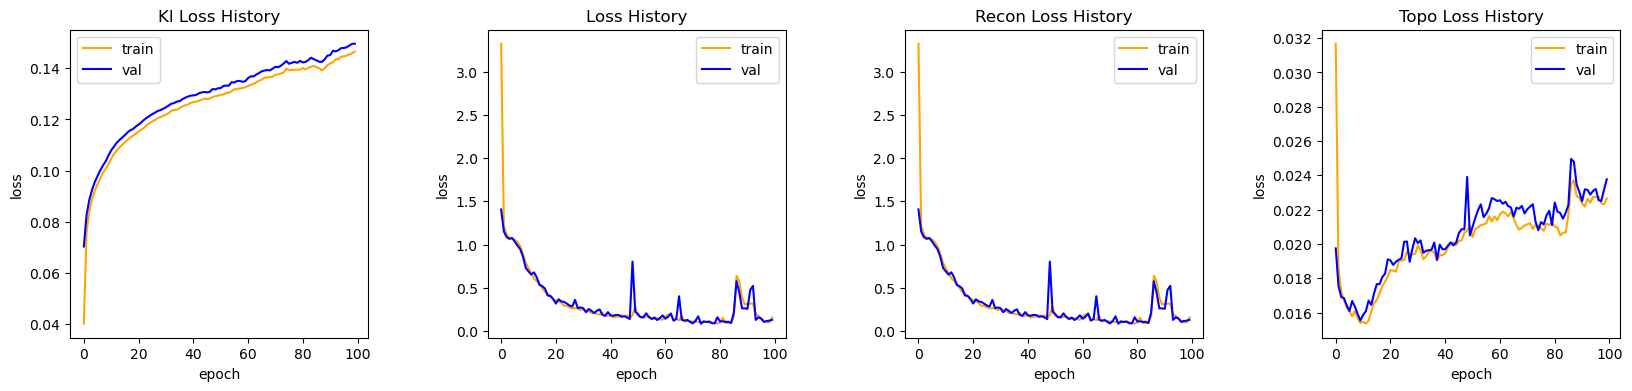

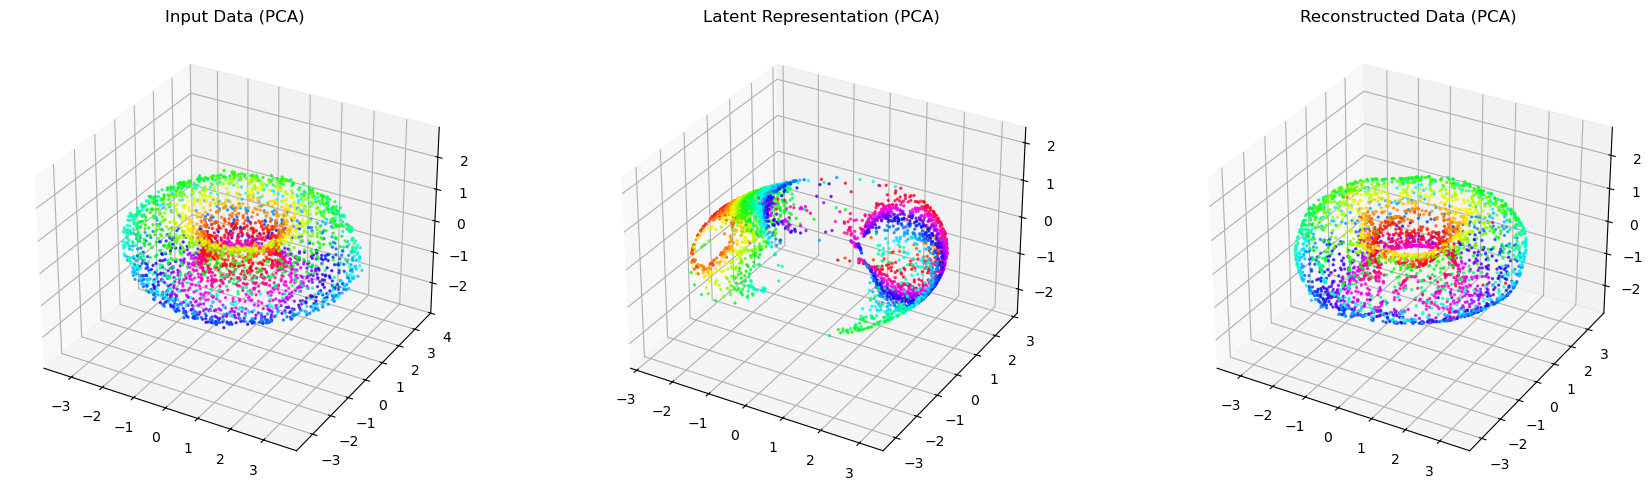

Execution time exp00_t_vae_torus_high: 440.8278 seconds

Running exp01_t_vae_torus_high. 
Description: beta=0.08, gamma=0.0, dim_topo_loss=0
--------------------------------------------------------------------------------------


<Figure size 640x480 with 0 Axes>

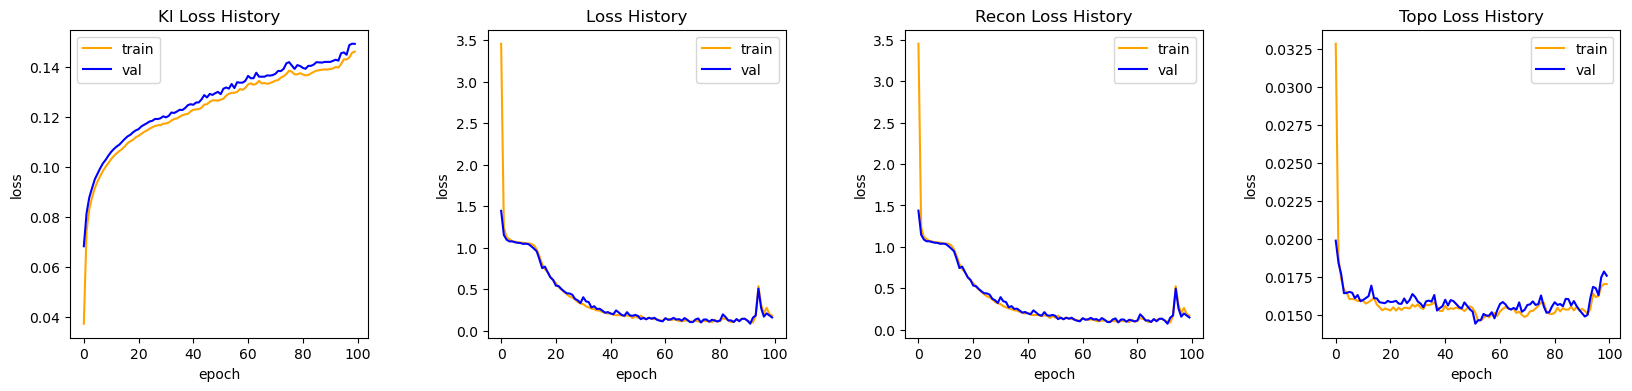

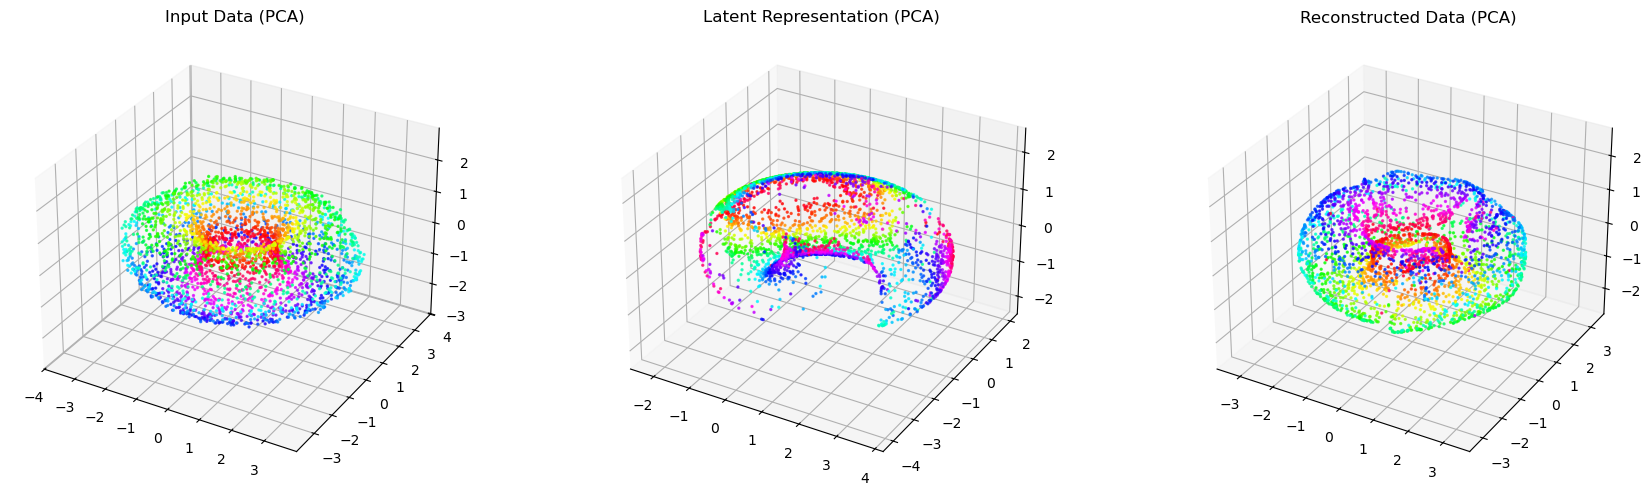

Execution time exp01_t_vae_torus_high: 864.0634 seconds

Running exp02_t_vae_torus_high. 
Description: beta=1.0, gamma=0.0, dim_topo_loss=0
--------------------------------------------------------------------------------------


<Figure size 640x480 with 0 Axes>

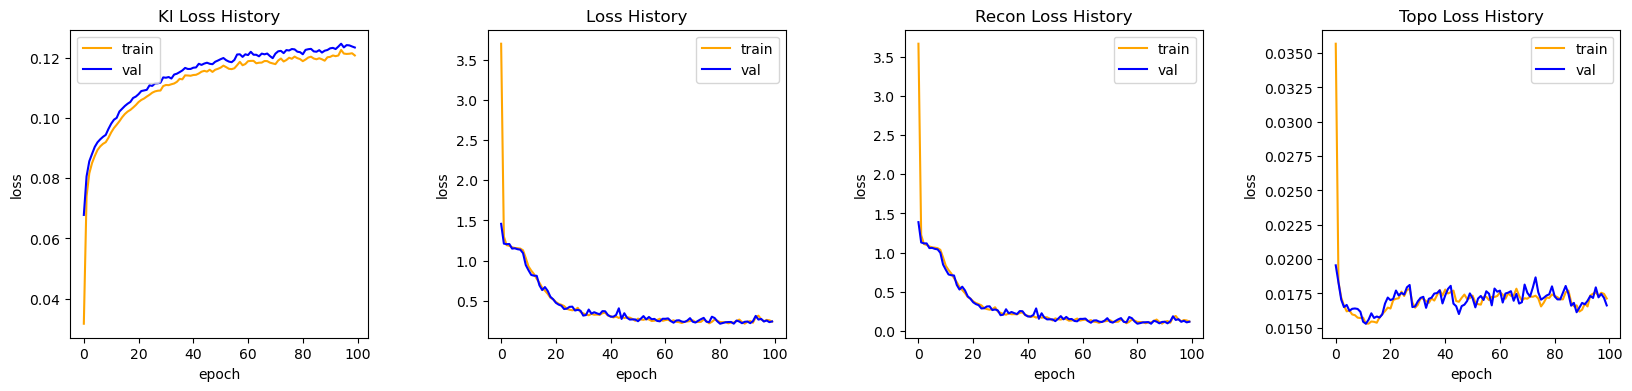

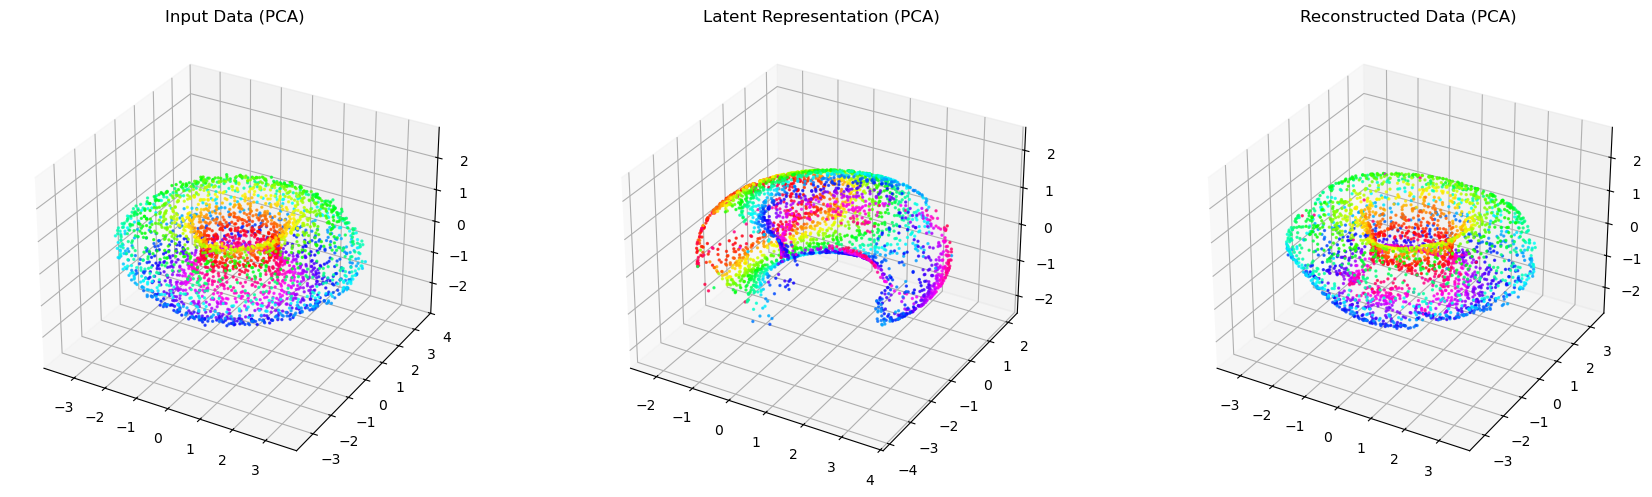

Execution time exp02_t_vae_torus_high: 1294.1714 seconds

Running exp03_t_vae_torus_high. 
Description: beta=0.0, gamma=1.0, dim_topo_loss=0
--------------------------------------------------------------------------------------


Epoch 87/100:  77%|████████████████████▋      | 108/141 [00:03<00:00, 35.56it/s]

In [ ]:
run_experiment(all_configs=all_configs)